# 06 - Threshold Tuning

Sweep thresholds against a business cost matrix (false-negative = missed fraud costs more than a false-positive = unnecessary block).
Find the threshold that minimises total business cost.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import joblib
from pathlib import Path

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    confusion_matrix, ConfusionMatrixDisplay,
    precision_recall_curve, average_precision_score, roc_auc_score,
)

import warnings
warnings.filterwarnings('ignore')

MODELS_PATH  = Path('../outputs/models')
FIGURES_PATH = Path('../outputs/figures')
FIGURES_PATH.mkdir(parents=True, exist_ok=True)


A module that was compiled using NumPy 1.x cannot be run in
NumPy 2.2.6 as it may crash. To support both 1.x and 2.x
versions of NumPy, modules must be compiled with NumPy 2.0.
Some module may need to rebuild instead e.g. with 'pybind11>=2.12'.

If you are a user of the module, the easiest solution will be to
downgrade to 'numpy<2' or try to upgrade the affected module.
We expect that some modules will need time to support NumPy 2.

Traceback (most recent call last):  File "<frozen runpy>", line 198, in _run_module_as_main
  File "<frozen runpy>", line 88, in _run_code
  File "C:\ProgramData\anaconda3\Lib\site-packages\ipykernel_launcher.py", line 17, in <module>
    app.launch_new_instance()
  File "C:\ProgramData\anaconda3\Lib\site-packages\traitlets\config\application.py", line 1075, in launch_instance
    app.start()
  File "C:\ProgramData\anaconda3\Lib\site-packages\ipykernel\kernelapp.py", line 701, in start
    self.io_loop.start()
  File "C:\Users\New User\AppData\Roaming\Pyth

AttributeError: _ARRAY_API not found


A module that was compiled using NumPy 1.x cannot be run in
NumPy 2.2.6 as it may crash. To support both 1.x and 2.x
versions of NumPy, modules must be compiled with NumPy 2.0.
Some module may need to rebuild instead e.g. with 'pybind11>=2.12'.

If you are a user of the module, the easiest solution will be to
downgrade to 'numpy<2' or try to upgrade the affected module.
We expect that some modules will need time to support NumPy 2.

Traceback (most recent call last):  File "<frozen runpy>", line 198, in _run_module_as_main
  File "<frozen runpy>", line 88, in _run_code
  File "C:\ProgramData\anaconda3\Lib\site-packages\ipykernel_launcher.py", line 17, in <module>
    app.launch_new_instance()
  File "C:\ProgramData\anaconda3\Lib\site-packages\traitlets\config\application.py", line 1075, in launch_instance
    app.start()
  File "C:\ProgramData\anaconda3\Lib\site-packages\ipykernel\kernelapp.py", line 701, in start
    self.io_loop.start()
  File "C:\Users\New User\AppData\Roaming\Pyth

ImportError: 
A module that was compiled using NumPy 1.x cannot be run in
NumPy 2.2.6 as it may crash. To support both 1.x and 2.x
versions of NumPy, modules must be compiled with NumPy 2.0.
Some module may need to rebuild instead e.g. with 'pybind11>=2.12'.

If you are a user of the module, the easiest solution will be to
downgrade to 'numpy<2' or try to upgrade the affected module.
We expect that some modules will need time to support NumPy 2.



## 1. Load model and data

In [2]:
df = pd.read_csv('../data/raw/creditcard.csv')
df['log_amount']  = np.log1p(df['Amount'])
df['hour_of_day'] = (df['Time'] // 3600) % 24
df = df.drop(columns=['Time', 'Amount'])

X = df.drop(columns=['Class'])
y = df['Class']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

model = joblib.load(MODELS_PATH / 'best_xgb.pkl')
print(f'Model       : {type(model).__name__}')
print(f'Test samples: {len(X_test):,}')
print(f'Fraud cases : {y_test.sum()}')

Model       : XGBClassifier
Test samples: 56,962
Fraud cases : 98


## 2. Predicted probabilities

In [3]:
y_proba = model.predict_proba(X_test)[:, 1]

print(f'Probability range : {y_proba.min():.4f} - {y_proba.max():.4f}')
print(f'Scores > 0.50     : {(y_proba > 0.50).sum()}')
print(f'Scores > 0.10     : {(y_proba > 0.10).sum()}')
print(f'Actual fraud count: {y_test.sum()}')

Probability range : 0.0000 - 1.0000
Scores > 0.50     : 97
Scores > 0.10     : 121
Actual fraud count: 98


## 3. Business cost matrix

| Outcome | Meaning | Cost |
|---------|---------|------|
| False Negative (FN) | Fraud missed, transaction approved | $500 |
| False Positive (FP) | Legit transaction blocked | $10 |

FN is 50x more expensive than FP - we should lower the threshold to catch more fraud.

In [4]:
COST_FN = 500   # missed fraud - approximate average fraud loss
COST_FP = 10    # false alarm - customer friction + investigation

thresholds = np.linspace(0.01, 0.99, 200)
costs      = []

for t in thresholds:
    y_pred = (y_proba >= t).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()
    costs.append(fn * COST_FN + fp * COST_FP)

costs = np.array(costs)

optimal_idx       = costs.argmin()
optimal_threshold = thresholds[optimal_idx]
optimal_cost      = int(costs[optimal_idx])

default_cost = int(costs[np.argmin(np.abs(thresholds - 0.5))])

print(f'Cost at default threshold (0.50): ${default_cost:,}')
print(f'Optimal threshold               : {optimal_threshold:.2f}')
print(f'Minimum cost                    : ${optimal_cost:,}')
print(f'Cost saving vs default          : ${default_cost - optimal_cost:,}')

Cost at default threshold (0.50): $8,150
Optimal threshold               : 0.03
Minimum cost                    : $5,800
Cost saving vs default          : $2,350


## 4. Cost curve

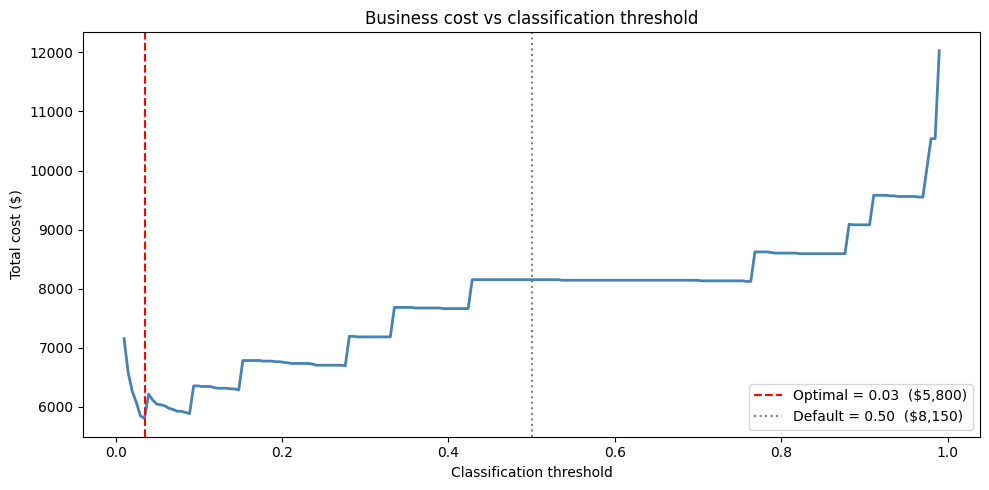

In [5]:
fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(thresholds, costs, color='steelblue', linewidth=2)
ax.axvline(optimal_threshold, color='red',  linestyle='--', label=f'Optimal = {optimal_threshold:.2f}  (${optimal_cost:,})')
ax.axvline(0.5,               color='grey', linestyle=':',  label=f'Default = 0.50  (${default_cost:,})')
ax.set_xlabel('Classification threshold')
ax.set_ylabel('Total cost ($)')
ax.set_title('Business cost vs classification threshold')
ax.legend()
plt.tight_layout()
plt.savefig(FIGURES_PATH / '06_cost_curve.png', dpi=150, bbox_inches='tight')
plt.show()

## 5. Precision-Recall tradeoff

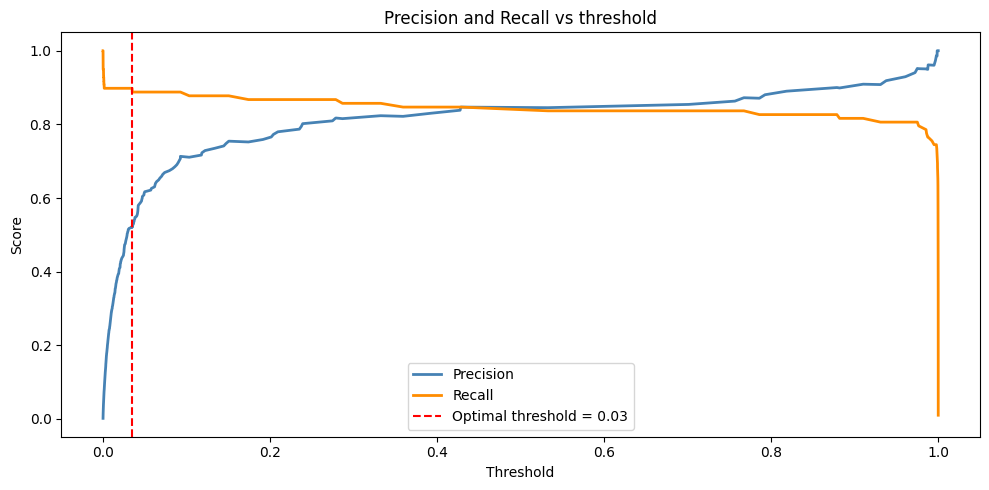

In [6]:
precision, recall, pr_thresholds = precision_recall_curve(y_test, y_proba)

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(pr_thresholds, precision[:-1], label='Precision', color='steelblue',  linewidth=2)
ax.plot(pr_thresholds, recall[:-1],    label='Recall',    color='darkorange', linewidth=2)
ax.axvline(optimal_threshold, color='red', linestyle='--',
           label=f'Optimal threshold = {optimal_threshold:.2f}')
ax.set_xlabel('Threshold')
ax.set_ylabel('Score')
ax.set_title('Precision and Recall vs threshold')
ax.legend()
plt.tight_layout()
plt.savefig(FIGURES_PATH / '06_precision_recall_threshold.png', dpi=150, bbox_inches='tight')
plt.show()

## 6. Confusion matrix comparison

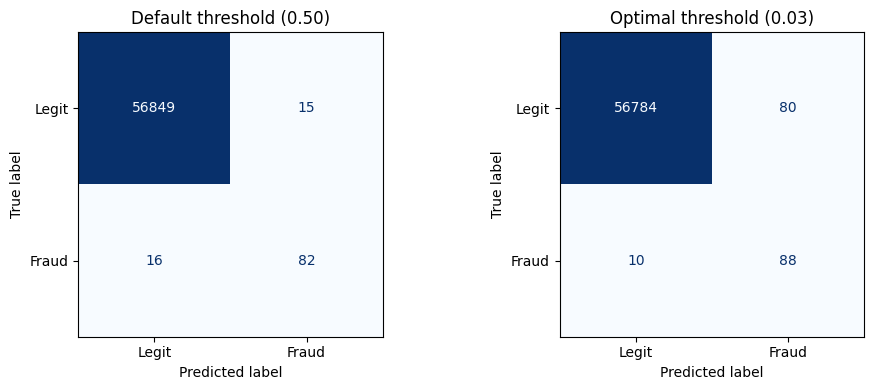

In [7]:
y_pred_default = (y_proba >= 0.50).astype(int)
y_pred_optimal = (y_proba >= optimal_threshold).astype(int)

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
for ax, y_pred, title in zip(
    axes,
    [y_pred_default, y_pred_optimal],
    [f'Default threshold (0.50)', f'Optimal threshold ({optimal_threshold:.2f})'],
):
    cm = confusion_matrix(y_test, y_pred)
    ConfusionMatrixDisplay(cm, display_labels=['Legit', 'Fraud']).plot(
        ax=ax, colorbar=False, cmap='Blues'
    )
    ax.set_title(title)
plt.tight_layout()
plt.savefig(FIGURES_PATH / '06_confusion_matrix_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

## 7. Final model summary

In [8]:
tn, fp, fn, tp = confusion_matrix(y_test, y_pred_optimal).ravel()

print('=== FINAL MODEL SUMMARY ===')
print(f'Model:             XGBoost (Optuna tuned)')
print(f'Optimal threshold: {optimal_threshold:.2f}')
print(f'Fraud caught:      {tp} / {y_test.sum()} ({tp/y_test.sum()*100:.1f}%)')
print(f'Fraud missed:      {fn}')
print(f'False alarms:      {fp}')
print(f'Cost saving vs default threshold: ${default_cost - optimal_cost:,}')
print(f'Total cost at optimal threshold:  ${optimal_cost:,}')
print()
print('Next: notebook 07 - wrap model in FastAPI and deploy to Render')

=== FINAL MODEL SUMMARY ===
Model:             XGBoost (Optuna tuned)
Optimal threshold: 0.03
Fraud caught:      88 / 98 (89.8%)
Fraud missed:      10
False alarms:      80
Cost saving vs default threshold: $2,350
Total cost at optimal threshold:  $5,800

Next: notebook 07 - wrap model in FastAPI and deploy to Render
